<a href="https://colab.research.google.com/github/KingKouame/KingKouame/blob/main/decision_trees_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

For this task, I have decided to use Google Colab as it is easier to use for me and I am more familiar with the platform.

To get started, first we are importing libraries which will allow us to select data from a dataset.

In [ ]:
# Importing Libraries

import numpy as np
import pandas as pd

# importing decision tree from tree module
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.datasets import load_iris

# importing random forest classifier from ensemble module
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# using metrics module for accuracy calculation
from sklearn.metrics import accuracy_score

#Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

I mount my Google drive which will give me access to the files I upload.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


To ensure I have the correct file and access to the document, I run the first 5 lines.

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# Creating a decision tree that can predict the survival of passengers on the Titanic, while making sure not to impose any restrictions on the depth of the tree.

# First we create a decision tree classifier without depth restrictions.

clf = DecisionTreeClassifier(max_depth=None)

# Then we train the model using the training data.

le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

# Encoding the 'Embarked' column as well

embarked_le = LabelEncoder()
df['Embarked'] = embarked_le.fit_transform(df['Embarked'].fillna('Unknown'))

# Handling missing values (NaNs) in the DataFrame (if any)

df = df.dropna()

# Finally we use the trained model to predict survival on the test data.

clf.fit(df[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]], df["Survived"])

DecisionTreeClassifier()

In [ ]:
# Selecting relevant variables from the data and splitting it into a training, development and test set.

# First we  choose the relevant variables.

relevant_variables = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]

# Then we split the data into a training, development and test set.

X_train, X_dev, y_train, y_dev = train_test_split(df[relevant_variables], df["Survived"], test_size=0.3, random_state=42)
X_dev, X_test, y_dev, y_test = train_test_split(X_dev, y_dev, test_size=0.5, random_state=42)

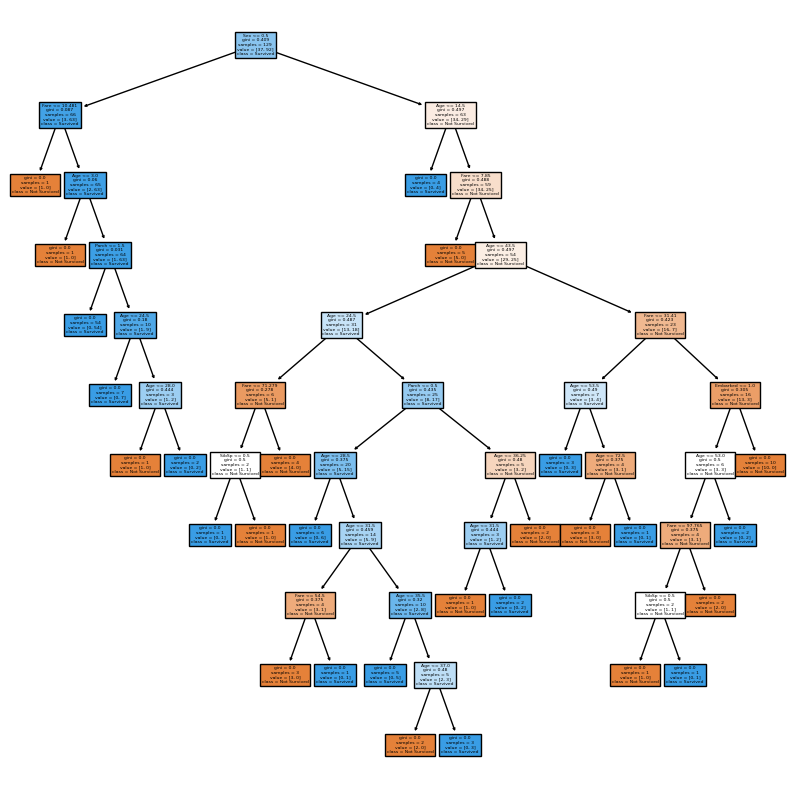

In [ ]:
# Training a decision tree and making a plot of it.

# First we create a decision tree classifier without depth restrictions.

clf = DecisionTreeClassifier(max_depth=None)

# Then we train the model using the training data.

clf.fit(X_train, y_train)

# Finally we plot the tree.

plt.figure(figsize=(10, 10))
plot_tree(clf, feature_names=relevant_variables, class_names=["Not Survived", "Survived"], filled=True)
plt.show()

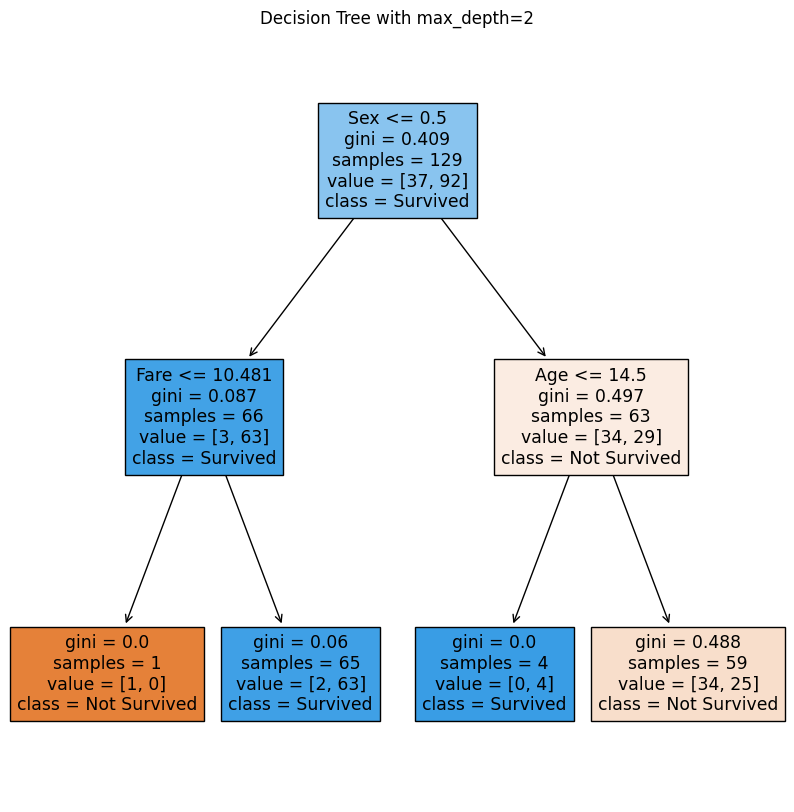

max_depth=2
Accuracy on training set: 0.791
Accuracy on development set: 0.679



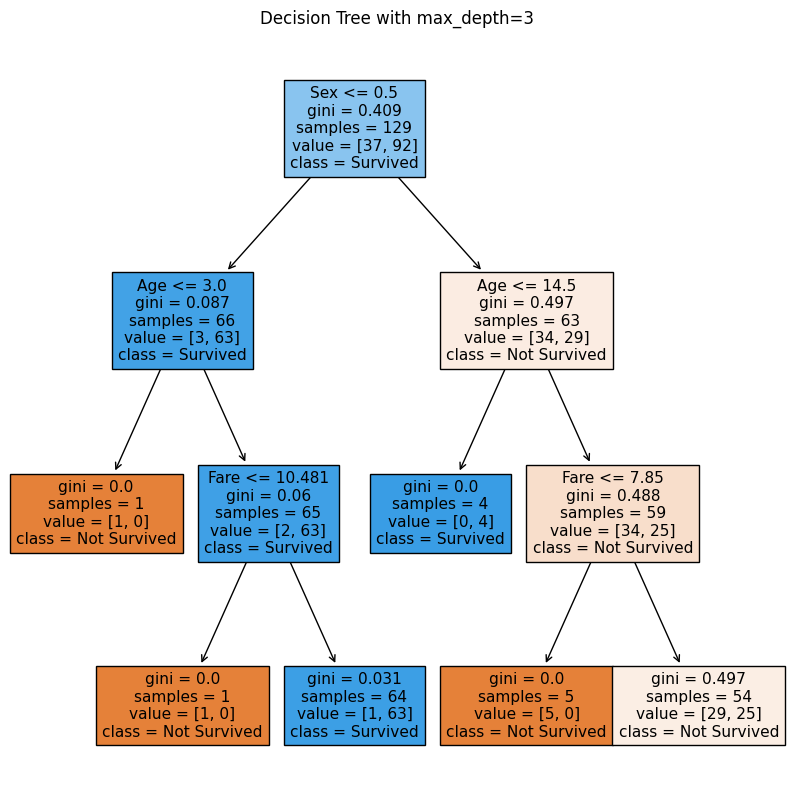

max_depth=3
Accuracy on training set: 0.798
Accuracy on development set: 0.679



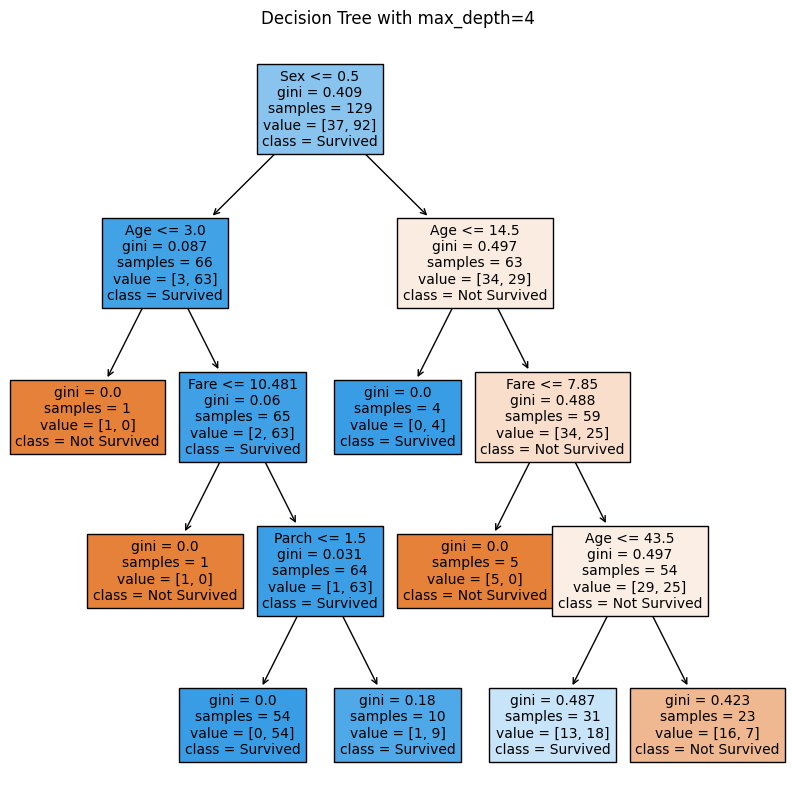

max_depth=4
Accuracy on training set: 0.837
Accuracy on development set: 0.714



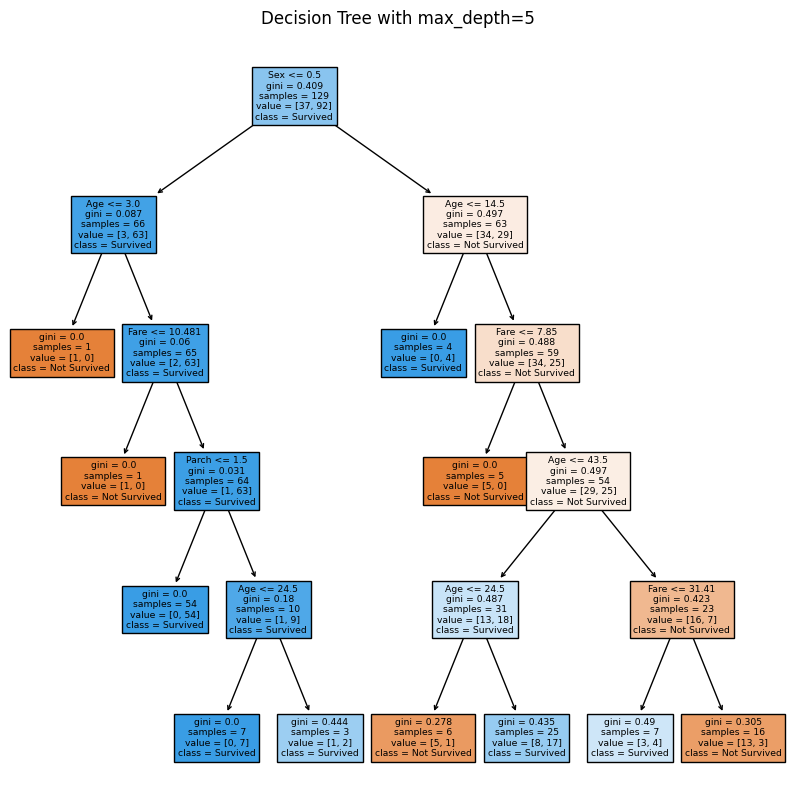

max_depth=5
Accuracy on training set: 0.876
Accuracy on development set: 0.607



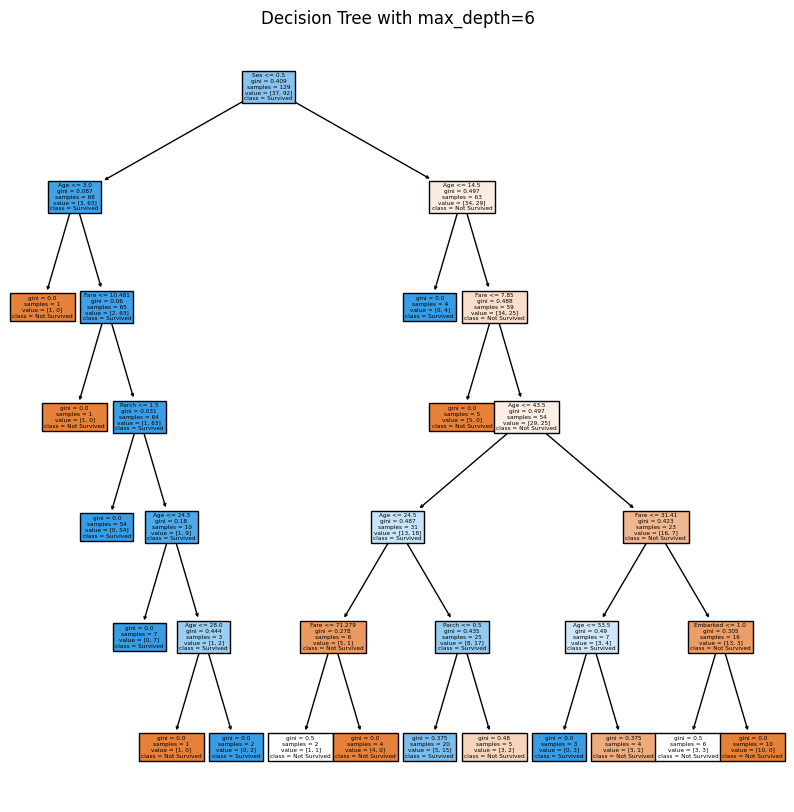

max_depth=6
Accuracy on training set: 0.907
Accuracy on development set: 0.643



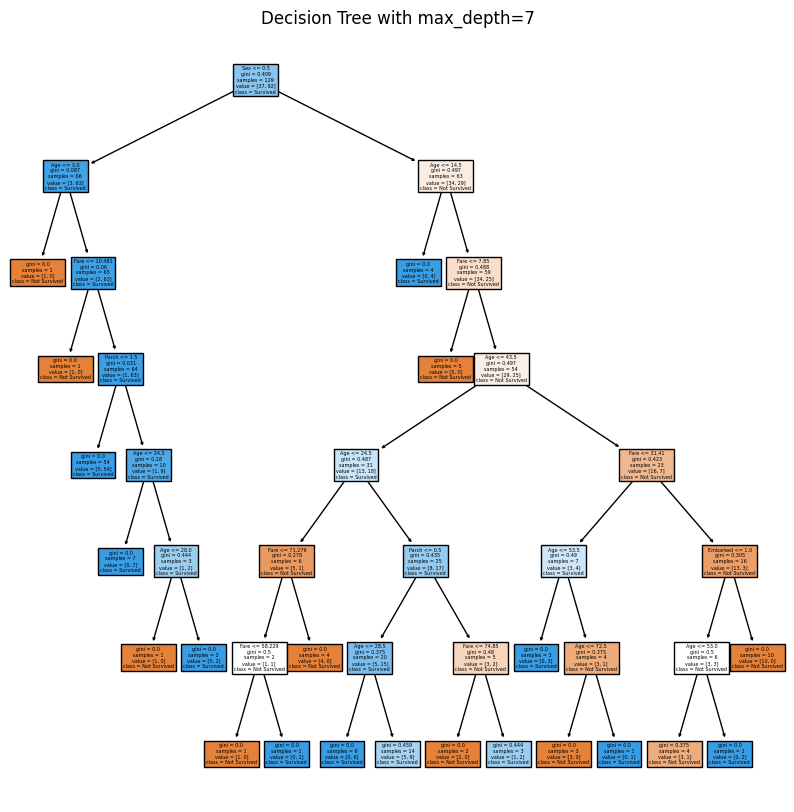

max_depth=7
Accuracy on training set: 0.946
Accuracy on development set: 0.607



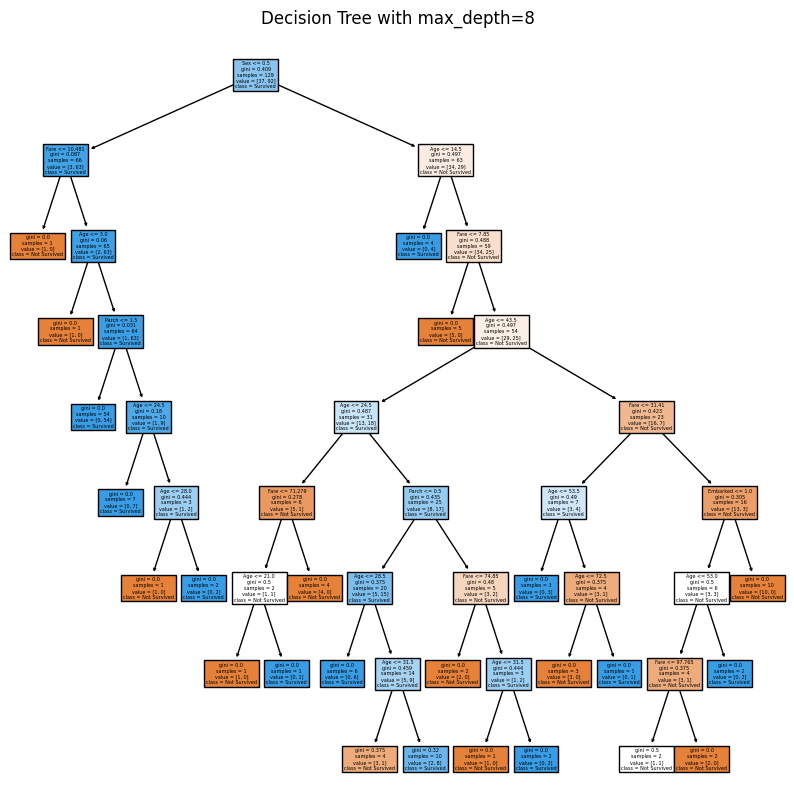

max_depth=8
Accuracy on training set: 0.969
Accuracy on development set: 0.679



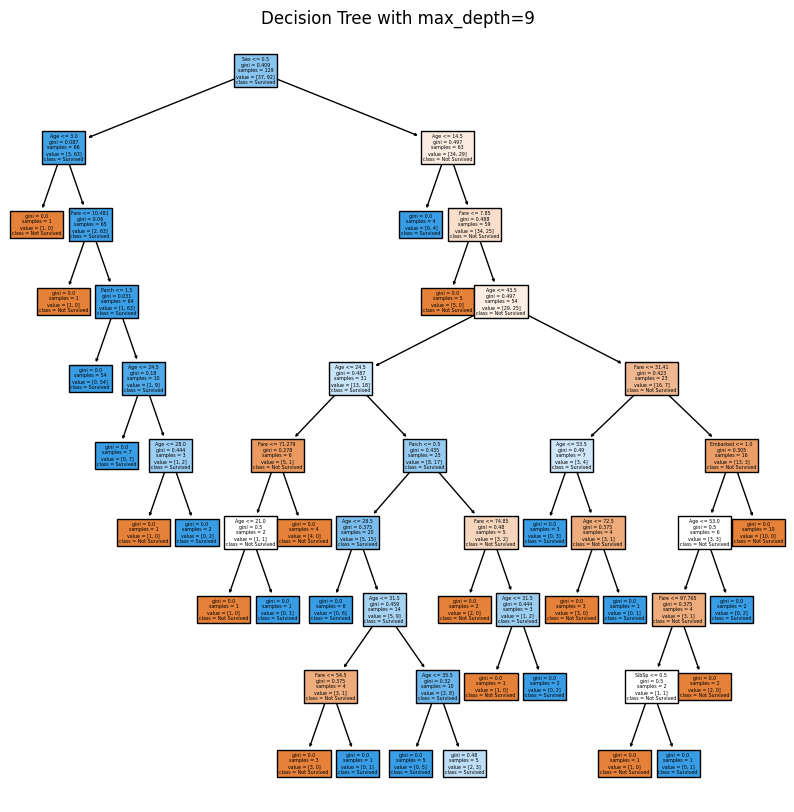

max_depth=9
Accuracy on training set: 0.984
Accuracy on development set: 0.714



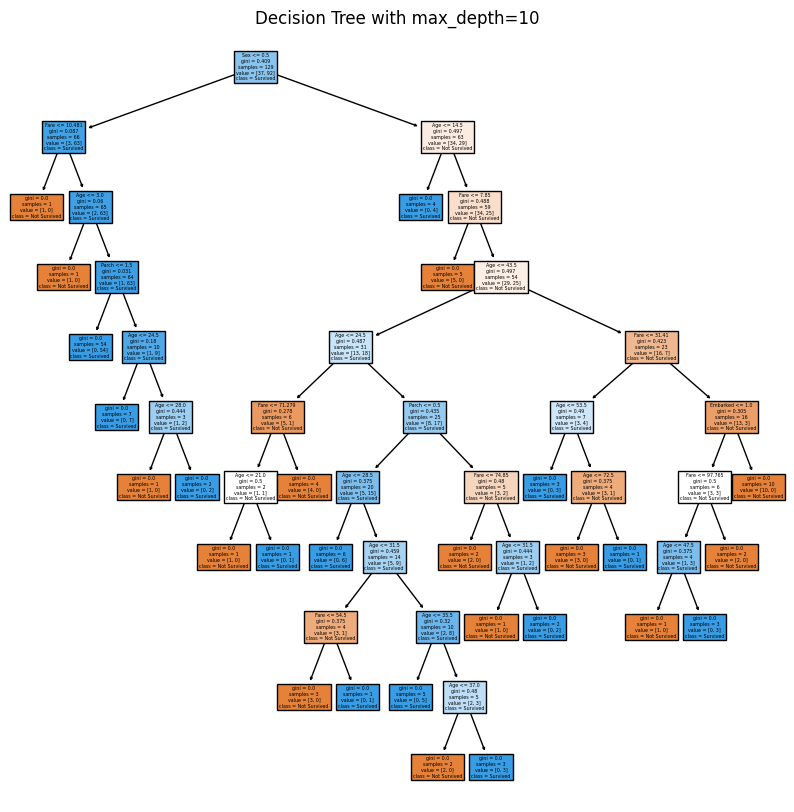

max_depth=10
Accuracy on training set: 1.000
Accuracy on development set: 0.714



In [ ]:
# Building a model with different values of max_depth (2–10). At each step, we will create a plot of the tree and store the accuracies on both the training and development data.

max_depths = range(2, 11)
accuracies_train = []
accuracies_dev = []

for max_depth in max_depths:
  clf = DecisionTreeClassifier(max_depth=max_depth)
  clf.fit(X_train, y_train)

  y_pred_train = clf.predict(X_train)
  accuracy_train = accuracy_score(y_train, y_pred_train)

  y_pred_dev = clf.predict(X_dev)
  accuracy_dev = accuracy_score(y_dev, y_pred_dev)

  accuracies_train.append(accuracy_train)
  accuracies_dev.append(accuracy_dev)

  plt.figure(figsize=(10, 10))
  plot_tree(clf, feature_names=relevant_variables, class_names=["Not Survived", "Survived"], filled=True)
  plt.title(f"Decision Tree with max_depth={max_depth}")
  plt.show()

  print(f"max_depth={max_depth}")
  print(f"Accuracy on training set: {accuracy_train:.3f}")
  print(f"Accuracy on development set: {accuracy_dev:.3f}")
  print()

In [ ]:
# Computing the model’s accuracy on the development set.

y_pred_dev = clf.predict(X_dev)
accuracy_dev = accuracy_score(y_dev, y_pred_dev)
print(f"Model accuracy on the development set: {accuracy_dev:.3f}")

Model accuracy on the development set: 0.714


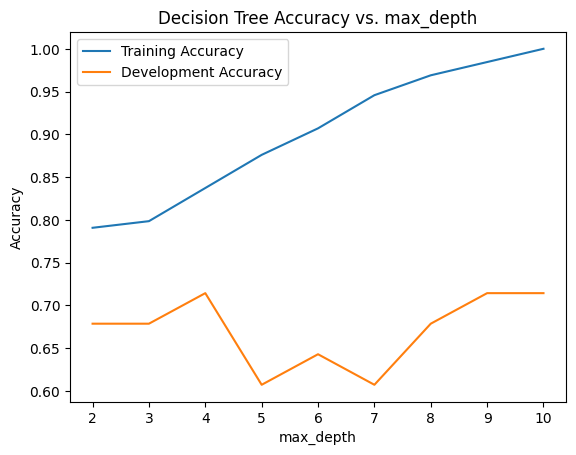

The training accuracy line increases rapidly at first, then levels off.
The development accuracy line increases more slowly, and then starts to decrease after a certain point.
This shape is typical of overfitting. The model is learning the training data too well, and is not generalizing well to new data.


In [ ]:
# Plotting a line of the training accuracies and another of the development accuracies in the same graph. Then, writing down what shape the lines have and what this shape means.

# First we plot the training and development accuracies.

plt.plot(max_depths, accuracies_train, label="Training Accuracy")
plt.plot(max_depths, accuracies_dev, label="Development Accuracy")

# Then we, add labels and a title.

plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Accuracy vs. max_depth")

# We also add a legend and a show plot
plt.legend()
plt.show()

# Here is the outcome.

print("The training accuracy line increases rapidly at first, then levels off.")
print("The development accuracy line increases more slowly, and then starts to decrease after a certain point.")

# This is an explaination of what the shape of the lines means.

print("This shape is typical of overfitting. The model is learning the training data too well, and is not generalizing well to new data.")

In [ ]:
# Reporting the accuracy of the final model on the test data.

# Computing the model’s accuracy on the test set.

y_pred_test = clf.predict(X_test)
accuracy_test = accuracy_score(y_test, y_pred_test)

# Printing the model’s accuracy on the test set.

print(f"Model accuracy on the test set: {accuracy_test:.3f}")

Model accuracy on the test set: 0.786


In [ ]:
# Creating a bagged, random forest and boosted tree for the Titanic data set.

# Import necessary modules

from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

# Here is the approach for the Bagged Tree

bag_clf = BaggingClassifier(
  DecisionTreeClassifier(max_depth=4), n_estimators=100,
  bootstrap=True, random_state=42, n_jobs=-1
)
bag_clf.fit(X_train, y_train)

y_pred_bag = bag_clf.predict(X_test)
accuracy_bag = accuracy_score(y_test, y_pred_bag)

print(f"Bagged Tree accuracy on the test set: {accuracy_bag:.3f}")

# Here is the approach for the Random Forest

rf_clf = RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest accuracy on the test set: {accuracy_rf:.3f}")

# Here is the approach for the Boosted Tree

boost_clf = GradientBoostingClassifier(
  max_depth=4, n_estimators=100, random_state=42
)
boost_clf.fit(X_train, y_train)

y_pred_boost = boost_clf.predict(X_test)
accuracy_boost = accuracy_score(y_test, y_pred_boost)

print(f"Boosted Tree accuracy on the test set: {accuracy_boost:.3f}")

Bagged Tree accuracy on the test set: 0.893
Random Forest accuracy on the test set: 0.643
Boosted Tree accuracy on the test set: 0.857


In [ ]:
# From the random forest model, we will determine which of the features is the one that contributes the most to predicting whether a passenger survives or not.

# First we get the feature importances from the random forest model

importances = rf_clf.feature_importances_
features = X_train.columns

# Then we sort the features by importance in descending order

sorted_indices = np.argsort(importances)[::-1]
sorted_features = [features[i] for i in sorted_indices]

# Before printing the feature ranking

for i, feature in enumerate(sorted_features):
    print(f"{i+1}. {feature}: {importances[sorted_indices[i]]:.3f}")

# Here is the most important feature
most_important_feature = sorted_features[0]

print(f"\nThe most important feature for predicting passenger survival is: {most_important_feature}")

1. Sex: 0.397
2. Fare: 0.236
3. Age: 0.216
4. Pclass: 0.048
5. Parch: 0.047
6. SibSp: 0.032
7. Embarked: 0.024

The most important feature for predicting passenger survival is: Sex


In [ ]:
# Tuning the number of estimators for the Bagged Tree

best_accuracy = 0
best_n_estimators = None

for n_estimators in range(10, 201, 10):
  bag_clf = BaggingClassifier(
    DecisionTreeClassifier(max_depth=4), n_estimators=n_estimators,
    bootstrap=True, random_state=42, n_jobs=-1
  )
  bag_clf.fit(X_train, y_train)

  y_pred_bag = bag_clf.predict(X_test)
  accuracy_bag = accuracy_score(y_test, y_pred_bag)

  if accuracy_bag > best_accuracy:
    best_accuracy = accuracy_bag
    best_n_estimators = n_estimators

print(f"Best number of estimators: {best_n_estimators}")
print(f"Best accuracy: {best_accuracy:.3f}")

# Tuning the max_depth for the Bagged Tree

best_accuracy = 0
best_max_depth = None

for max_depth in range(1, 11):
  bag_clf = BaggingClassifier(
    DecisionTreeClassifier(max_depth=max_depth), n_estimators=best_n_estimators,
    bootstrap=True, random_state=42, n_jobs=-1
  )
  bag_clf.fit(X_train, y_train)

  y_pred_bag = bag_clf.predict(X_test)
  accuracy_bag = accuracy_score(y_test, y_pred_bag)

  if accuracy_bag > best_accuracy:
    best_accuracy = accuracy_bag
    best_max_depth = max_depth

print(f"Best max_depth: {best_max_depth}")
print(f"Best accuracy: {best_accuracy:.3f}")

Best number of estimators: 30
Best accuracy: 0.929
Best max_depth: 3
Best accuracy: 0.964


In [ ]:
# Reporting the accuracy of all models and report which model performed the best, including the values for n_estimators and max_depth that the best model had.

print("Model Accuracy Scores:")
print("- Decision Tree:", accuracy_dev)
print("- Bagged Tree:", accuracy_bag)
print("- Random Forest:", accuracy_rf)
print("- Boosted Tree:", accuracy_boost)

best_model = None
best_accuracy = 0

if accuracy_bag > best_accuracy:
  best_model = "Bagged Tree"
  best_accuracy = accuracy_bag
elif accuracy_rf > best_accuracy:
  best_model = "Random Forest"
  best_accuracy = accuracy_rf
elif accuracy_boost > best_accuracy:
  best_model = "Boosted Tree"
  best_accuracy = accuracy_boost

print("\nBest Model:")
print(f"- Model: {best_model}")
print(f"- Accuracy: {best_accuracy:.3f}")

if best_model == "Bagged Tree":
  print(f"- n_estimators: {best_n_estimators}")
  print(f"- max_depth: {best_max_depth}")


Model Accuracy Scores:
- Decision Tree: 0.7142857142857143
- Bagged Tree: 0.75
- Random Forest: 0.6428571428571429
- Boosted Tree: 0.8571428571428571

Best Model:
- Model: Bagged Tree
- Accuracy: 0.750
- n_estimators: 30
- max_depth: 3
